In [1]:

import osmnx as ox
import os
from dotenv import load_dotenv
import folium
import random
import networkx as nx
import heapq
import pandas as pd
import numpy as np
import time
import geopandas as gpd
from shapely.geometry import LineString
from itertools import combinations
load_dotenv()

apikey = os.getenv("THUNDERFOREST_API_KEY")

In [3]:
z = 400
x = 40.006067
y = -105.264977

In [4]:
ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["surface"]
graph = ox.graph_from_point((x, y), dist=z, network_type='walk')

In [5]:
# Approach 1: Query landuse=grass features
tags_landuse = {'landuse': ['grass', 'recreation_ground']}
grass_landuse_gdf = ox.features_from_point((x,y), tags=tags_landuse, dist=z)

# Approach 2: Query surface=grass features  
tags_surface = {'surface': ['grass', 'lawn', 'turf']}
grass_surface_gdf = ox.features_from_point((x,y), tags=tags_surface, dist=z)

natural_grass_gdf = ox.features_from_point((x,y), tags={'natural': 'grassland'}, dist=z)

# Combine both GeoDataFrames to get all grass features
grass_gdf = pd.concat([grass_landuse_gdf, grass_surface_gdf, natural_grass_gdf], ignore_index=True).drop_duplicates()

In [6]:
# edges_to_remove = [(u, v, k) for u, v, k, d in graph.edges(keys=True, data=True) if 'surface' not in d or d['surface'] is None]
# graph.remove_edges_from(edges_to_remove)

In [7]:
tags_building = {'building': True}
buildings_gdf = ox.features_from_point((x, y), tags=tags_building, dist=z)


In [9]:
# Get a random edge from the graph
random_edge = random.choice(list(graph.edges(keys=True, data=True)))

# Print all attributes of the random edge
print("Random edge attributes:")
for key, value in random_edge[3].items():
    print(f"{key}: {value}")


Random edge attributes:
osmid: 208190991
highway: footway
surface: concrete
oneway: False
reversed: True
length: 4.810880992617458


In [10]:
tile_layers = {
    "OpenCycleMap": f"https://tile.thunderforest.com/cycle/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Transport": f"https://tile.thunderforest.com/transport/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Landscape": f"https://tile.thunderforest.com/landscape/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Outdoors": f"https://tile.thunderforest.com/outdoors/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Transport Dark": f"https://tile.thunderforest.com/transport-dark/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Spinal Map": f"https://tile.thunderforest.com/spinal-map/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Pioneer": f"https://tile.thunderforest.com/pioneer/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Mobile Atlas": f"https://tile.thunderforest.com/mobile-atlas/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Neighbourhood": f"https://tile.thunderforest.com/neighbourhood/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
    "Atlas": f"https://tile.thunderforest.com/atlas/{{z}}/{{x}}/{{y}}.png?apikey={apikey}",
}

# Create a folium map centered at your point
m = folium.Map(location=[x, y], zoom_start=15.5)

# Add your custom tile layers
for name, url in tile_layers.items():
    folium.TileLayer(
        tiles=url,
        attr='Thunderforest',
        name=name
    ).add_to(m)

# Add the grass areas to the map
folium.GeoJson(
    grass_gdf,
    style_function=lambda x: {
        'color': 'green',
        'weight': 2,
        'opacity': 0.8,
        'fillColor': 'lightgreen',
        'fillOpacity': 0.6
    }
).add_to(m)

# Add buildings to the map
folium.GeoJson(
    buildings_gdf,
    style_function=lambda x: {
        'color': 'yellow',
        'weight': 1,
        'opacity': 0.8,
        'fillColor': 'darkgray',
        'fillOpacity': 0.6
    }
).add_to(m)

# Convert graph to GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(graph)

# Add edges (streets) to the map
folium.GeoJson(
    edges_gdf,
    style_function=lambda x: {
        'color': 'blue',
        'weight': 2,
        'opacity': 0.8
    }
).add_to(m)

# Optionally add nodes (intersections) to the map
for idx, row in nodes_gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color='red',
        fill=True,
        fillColor='red',
        fillOpacity=0.7,
        popup=f"Node: {idx}"
    ).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Display the map
m

In [11]:

def cluster_graph_by_nearest_grass(nodes_gdf, edges_gdf, grass_gdf, max_distance=20):
    """
    Clusters graph nodes and edges based on the nearest grass polygon.

    Each node/edge within the max_distance of any grass polygon is assigned a
    'cluster_id' corresponding to the ID of the nearest grass patch.

    Args:
        nodes_gdf (GeoDataFrame): GeoDataFrame of graph nodes.
        edges_gdf (GeoDataFrame): GeoDataFrame of graph edges.
        grass_gdf (GeoDataFrame): GeoDataFrame of grass polygons.
        max_distance (int): The maximum distance in meters to consider an element
                            part of a cluster.

    Returns:
        tuple: A tuple containing two modified GeoDataFrames:
               - nodes_with_clusters (GeoDataFrame): Nodes with a new 'cluster_id' column.
               - edges_with_clusters (GeoDataFrame): Edges with a new 'cluster_id' column.
    """
    # --- Step 1: Preparation ---
    
    # Create a clean, unique ID for each grass patch to use as the cluster ID.
    grass_with_id = grass_gdf.copy()
    grass_with_id['cluster_id'] = range(len(grass_with_id))

    # Project to a UTM CRS for accurate distance calculations
    utm_crs = nodes_gdf.estimate_utm_crs()
    nodes_proj = nodes_gdf.to_crs(utm_crs)
    edges_proj = edges_gdf.to_crs(utm_crs)
    grass_proj = grass_with_id.to_crs(utm_crs)

    # --- Step 2: Perform Nearest Neighbor Join ---
    
    # Use sjoin_nearest to find the single closest grass patch for each node and edge.
    # This is much more efficient than iterating.
    nodes_clustered_proj = gpd.sjoin_nearest(
        nodes_proj, grass_proj, how='left', max_distance=max_distance
    )
    edges_clustered_proj = gpd.sjoin_nearest(
        edges_proj, grass_proj, how='left', max_distance=max_distance
    )

    # --- Step 3: Map Cluster IDs back to original GeoDataFrames ---
    
    # Create the 'cluster_id' column in the original DataFrames.
    # It will be populated with NaN for elements not in any cluster.
    nodes_with_clusters = nodes_gdf.copy()
    edges_with_clusters = edges_gdf.copy()
    
    nodes_with_clusters['cluster_id'] = nodes_clustered_proj['cluster_id']
    edges_with_clusters['cluster_id'] = edges_clustered_proj['cluster_id']
    
    return nodes_with_clusters, edges_with_clusters

In [12]:
# --- Example Usage ---

# 1. Get your graph nodes and edges
nodes_gdf, edges_gdf = ox.graph_to_gdfs(graph)

# 2. Cluster nodes and edges by the nearest grass patch (up to 25m away)
nodes_clustered, edges_clustered = cluster_graph_by_nearest_grass(
    nodes_gdf, edges_gdf, grass_gdf, max_distance=5
)

print(f"Found {int(nodes_clustered['cluster_id'].max() + 1)} grass-based clusters.")
print(f"Clustered {nodes_clustered['cluster_id'].notna().sum()} nodes.")
print(f"Clustered {edges_clustered['cluster_id'].notna().sum()} edges.")
# --- 1. Generate All Potential New Edges within Clusters ---

# Create a set of existing edges from the original graph for fast lookups.
# We use frozenset for direction-independent checks ((u,v) == (v,u)).
original_nodes, original_edges = ox.graph_to_gdfs(graph)
existing_edges_set = set(
    frozenset(edge) for edge in original_edges.index.to_frame()[['u', 'v']].itertuples(index=False, name=None)
)

new_edges_list = []
# Get a list of unique, non-null cluster IDs to iterate over.
unique_cluster_ids = nodes_clustered['cluster_id'].dropna().unique()

# Project nodes once for accurate distance calculations in meters.
utm_crs = nodes_clustered.estimate_utm_crs()
nodes_proj = nodes_clustered.to_crs(utm_crs)

for cluster_id in unique_cluster_ids:
    cluster_nodes = nodes_clustered[nodes_clustered['cluster_id'] == cluster_id]
    
    # Only create edges if there's more than one node in the cluster.
    if len(cluster_nodes) > 1:
        # Create all unique pairs of nodes within the cluster.
        node_pairs = combinations(cluster_nodes.index, 2)
        
        for u, v in node_pairs:
            # Add edge only if it doesn't already exist in the original graph.
            if frozenset([u, v]) not in existing_edges_set:
                geom_u = cluster_nodes.loc[u, 'geometry']
                geom_v = cluster_nodes.loc[v, 'geometry']
                
                # Calculate accurate distance in meters.
                dist_meters = nodes_proj.loc[u, 'geometry'].distance(nodes_proj.loc[v, 'geometry'])
                
                new_edges_list.append({
                    'u': u, 'v': v, 'key': 0,
                    'geometry': LineString([geom_u, geom_v]),
                    'surface': 'grass',
                    'length': round(dist_meters, 2),
                    'highway': 'path',
                    'generated': 1 # Flag to identify these edges later if needed
                })

print(f"Generated {len(new_edges_list)} potential new grass path edges.")


# --- 2. Filter New Edges that Intersect with Buildings ---

# Proceed only if we have new edges to check and buildings to check against.
if new_edges_list and not buildings_gdf.empty:
    # Create a temporary GeoDataFrame for efficient spatial operations.
    new_edges_gdf = gpd.GeoDataFrame(new_edges_list, crs=original_edges.crs)
    
    # Project both to a common UTM CRS.
    edges_proj = new_edges_gdf.to_crs(utm_crs)
    buildings_proj = buildings_gdf.to_crs(utm_crs)
    
    # Create a single unified geometry of all buildings for a huge performance gain.
    all_buildings_union = buildings_proj.unary_union
    
    # Create a boolean mask of edges that DO NOT intersect the building footprints.
    non_intersecting_mask = ~edges_proj.intersects(all_buildings_union)
    
    # Filter the GeoDataFrame to keep only the valid edges.
    valid_new_edges_gdf = new_edges_gdf[non_intersecting_mask]
    
    print(f"Kept {len(valid_new_edges_gdf)} new edges after filtering for building intersection.")
    
elif not new_edges_list:
    print("No new edges were generated.")
    valid_new_edges_gdf = gpd.GeoDataFrame() # Ensure it's an empty GeoDataFrame
    
else: # new_edges_list exists, but buildings_gdf is empty
    print("No building data to filter against. Keeping all new edges.")
    valid_new_edges_gdf = gpd.GeoDataFrame(new_edges_list, crs=original_edges.crs)


# --- 3. Add Valid New Edges to the Original Graph ---

# If any valid new edges remain, combine them with the original graph edges.
if not valid_new_edges_gdf.empty:
    # Set the index correctly for the new edges before concatenation.
    valid_new_edges_gdf = valid_new_edges_gdf.set_index(['u', 'v', 'key'])
    
    # Combine the original edges with the new, filtered grass path edges.
    final_edges_gdf = pd.concat([original_edges, valid_new_edges_gdf])
    
    # Create the new, final graph from the original nodes and the combined edges.
    graph_with_grass_paths = ox.graph_from_gdfs(original_nodes, final_edges_gdf)
    
    print(f"Created new graph with {len(graph_with_grass_paths.edges())} total edges.")
    
else:
    print("No valid new edges to add. The original graph remains unchanged.")
    graph_with_grass_paths = graph # The new graph is the same as the old one.



Found 90 grass-based clusters.
Clustered 158 nodes.
Clustered 582 edges.
Generated 350 potential new grass path edges.


/var/folders/6l/3d7jmg7d6h942bjz6t9qqjzr0000gn/T/ipykernel_53838/3704129661.py:72: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  all_buildings_union = buildings_proj.unary_union


Kept 223 new edges after filtering for building intersection.
Created new graph with 1803 total edges.


In [13]:

# 1. Initialize the map with your custom tile layers
m = folium.Map(location=[x, y], zoom_start=15.5)
for name, url in tile_layers.items():
    folium.TileLayer(tiles=url, attr='Thunderforest', name=name).add_to(m)

# 2. Get the nodes and edges from your final graph
nodes_gdf, edges_gdf = ox.graph_to_gdfs(graph_with_grass_paths)

# 3. Separate the different types of edges for styling
street_paths_gdf = edges_gdf
# grass_paths_gdf = edges_gdf[edges_gdf['surface'] == 'grass']

# 4. Add layers to the map, matching your original styling

# Add Grass Polygons
folium.GeoJson(
    grass_gdf,
    style_function=lambda x: {
        'color': 'green', 'weight': 2, 'opacity': 0.8,
        'fillColor': 'lightgreen', 'fillOpacity': 0.6
    },
    name="Grass Areas"
).add_to(m)

# Add Building Footprints
folium.GeoJson(
    buildings_gdf,
    style_function=lambda x: {
        'color': 'yellow', 'weight': 1, 'opacity': 0.8,
        'fillColor': 'darkgray', 'fillOpacity': 0.6
    },
    name="Buildings"
).add_to(m)

# Add the Original Street Network (blue)
folium.GeoJson(
    street_paths_gdf,
    style_function=lambda x: {'color': 'blue', 'weight': 2, 'opacity': 0.8},
    name="Street Network"
).add_to(m)

# Add the new Generated Grass Paths (distinct dashed style)
# folium.GeoJson(
#     grass_paths_gdf,
#     style_function=lambda x: {
#         'color': '#50AA88', 'weight': 3.5, 'opacity': 0.9, 'dashArray': '5, 10' # Neon green, dashed
#     },
#     name="Generated Grass Paths"
# ).add_to(m)

# Add all Graph Nodes (red)
for idx, row in nodes_gdf.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color='red',
        fill=True,
        fillColor='red',
        fillOpacity=0.7,
        popup=f"Node: {idx}"
    ).add_to(m)


# 5. Add the layer control widget and display the map
folium.LayerControl().add_to(m)

m

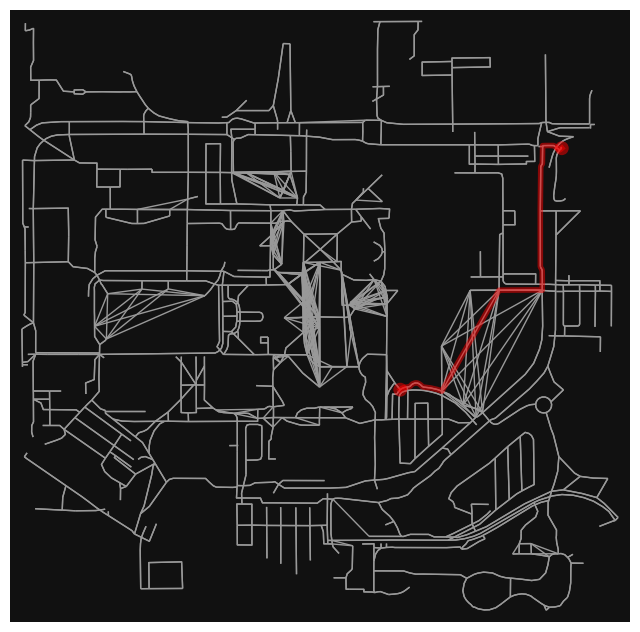

In [14]:

while True:
    try:
        # Get a list of all nodes in the graph
        all_nodes = list(graph_with_grass_paths.nodes())

        # Choose 2 random nodes
        origin = random.choice(all_nodes)
        destination = random.choice(all_nodes)

        # Make sure they're different
        while origin == destination:
            destination = random.choice(all_nodes)
            
        route1 = nx.shortest_path(graph_with_grass_paths, origin, destination, weight='length')
        fig, ax = ox.plot_graph_routes(graph_with_grass_paths, [route1], route_colors=['red'],
                                    route_linewidth=6, node_size=0)
        
        break
    except:
        continue


In [15]:
surface_types = []
for u, v, k, data in graph_with_grass_paths.edges(keys=True, data=True):
    if 'surface' in data and data['surface'] is not None:
        # Handle case where surface value might be a list by converting to string
        surface_value = data['surface']
        if isinstance(surface_value, (list, tuple)):
            surface_value = list(surface_value)
            surface_types.extend(surface_value)
        else:
            surface_types.append(surface_value)

surface_types = set(surface_types)
print("Surface types found:")
print(surface_types)

Surface types found:
{'concrete:plates', 'paved', 'paving_stones', 'grass', 'concrete', 'asphalt', 'brick'}
